## Data preprocessing and Random forest / XG boost

In [2]:
import pandas as pd


In [3]:
df = pd.read_csv(r'E:\competition\COmsic Classifier IIT Roorkie\Cosmic-Classifier\data\thermoracleTrain.csv')


In [4]:
df.sample(5)

,Atmospheric Density,Surface Temperature,Gravity,Water Content,Mineral Abundance,Orbital Period,Proximity to Star,Magnetic Field Strength,Radiation Levels,Atmospheric Composition Index,Prediction
38210,-0.983305,2.028942,0.968254,-0.402992,0.939706,2.122659,1.308124,Category_8,Category_11,-0.671836,NaN
47983,0.353239,-0.249242,2.619305,-1.095144,-1.342393,-1.090638,0.123008,Category_17,Category_11,-0.119778,5.0
38084,NaN,0.166717,0.630309,NaN,0.314410,-1.730850,-0.250599,Category_9,Category_7,-1.048952,6.0
23928,1.739168,-0.888954,-3.427789,-0.534172,-0.300864,-0.036736,-2.576991,Category_6,Category_8,-1.189371,5.0
34983,-1.040939,3.018895,1.038583,-1.622817,1.943708,0.791500,0.509695,Category_7,Category_10,-0.192517,9.0


In [5]:
df.isnull().sum()

Atmospheric Density              2984
Surface Temperature              3032
Gravity                          2984
Water Content                    3077
Mineral Abundance                2921
Orbital Period                   2997
Proximity to Star                2945
Magnetic Field Strength          3058
Radiation Levels                 3021
Atmospheric Composition Index    2942
Prediction                       3039
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Atmospheric Density            57016 non-null  float64
 1   Surface Temperature            56968 non-null  float64
 2   Gravity                        57016 non-null  float64
 3   Water Content                  56923 non-null  float64
 4   Mineral Abundance              57079 non-null  float64
 5   Orbital Period                 57003 non-null  float64
 6   Proximity to Star              57055 non-null  float64
 7   Magnetic Field Strength        56942 non-null  object 
 8   Radiation Levels               56979 non-null  object 
 9   Atmospheric Composition Index  57058 non-null  float64
 10  Prediction                     56961 non-null  float64
dtypes: float64(9), object(2)
memory usage: 5.0+ MB


In [7]:
df['Prediction'].isna().sum()

3039

In [8]:
df = df.dropna(subset=['Prediction'])

In [9]:
columns = ['Atmospheric Density',
'Gravity',
'Water Content',
'Mineral Abundance',
'Orbital Period',
'Proximity to Star',
'Atmospheric Composition Index',

'Surface Temperature']

In [10]:
df = pd.get_dummies(df , columns = ['Magnetic Field Strength' , 'Radiation Levels'])

In [11]:

# df["Water Content"] = df["Water Content"].apply(lambda x: max(x, 0))
# df["Mineral Abundance"] = df["Mineral Abundance"].apply(lambda x: max(x, 0))

In [12]:

for col in ["Atmospheric Density", "Gravity"]:
    median_value = df[df[col] > 0][col].median()
    df[col] = df[col].apply(lambda x: median_value if x < 0 else x)

In [13]:

columns_to_fix = ["Surface Temperature", "Orbital Period", "Proximity to Star","Water Content","Mineral Abundance"]


df[columns_to_fix] = df[columns_to_fix].abs()

In [15]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10),
    max_iter=5,
    random_state=36
)
df[columns] = imputer.fit_transform(df[columns])

C:\Users\Shiva\AppData\Roaming\Python\Python310\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [16]:
df = df.apply(pd.to_numeric, errors='coerce')
negative_counts = (df<0).sum()
print("Negative value counts:\n" , negative_counts[negative_counts > 0])

Negative value counts:
 Atmospheric Composition Index    27424
dtype: int64


In [17]:
df.isnull().sum()

Atmospheric Density                    0
Surface Temperature                    0
Gravity                                0
Water Content                          0
Mineral Abundance                      0
Orbital Period                         0
Proximity to Star                      0
Atmospheric Composition Index          0
Prediction                             0
Magnetic Field Strength_Category_1     0
Magnetic Field Strength_Category_10    0
Magnetic Field Strength_Category_11    0
Magnetic Field Strength_Category_12    0
Magnetic Field Strength_Category_13    0
Magnetic Field Strength_Category_14    0
Magnetic Field Strength_Category_15    0
Magnetic Field Strength_Category_16    0
Magnetic Field Strength_Category_17    0
Magnetic Field Strength_Category_18    0
Magnetic Field Strength_Category_19    0
Magnetic Field Strength_Category_2     0
Magnetic Field Strength_Category_20    0
Magnetic Field Strength_Category_3     0
Magnetic Field Strength_Category_4     0
Magnetic Field S

In [18]:

import pandas as pd
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

for col in numeric_cols:
    non_null_mask = ~df[col].isna()
    non_null_data = df.loc[non_null_mask, col].values.reshape(-1, 1)

    transformer = PowerTransformer(method='yeo-johnson')
    transformed_values = transformer.fit_transform(non_null_data).flatten()

    df[f"{col}_power"] = df[col].copy()
    df.loc[non_null_mask, f"{col}_power"] = transformed_values

    print(f"Lambda for {col}: {transformer.lambdas_[0]:.4f}")

Lambda for Atmospheric Density: -0.2748
Lambda for Surface Temperature: 0.1933
Lambda for Gravity: -0.0318
Lambda for Water Content: -0.1069
Lambda for Mineral Abundance: -0.1719
Lambda for Orbital Period: -0.1088
Lambda for Proximity to Star: -0.2034
Lambda for Atmospheric Composition Index: 1.1239
Lambda for Prediction: 0.6885


In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
from xgboost import XGBClassifier


X = df.drop(columns=['Prediction'])
y = df['Prediction']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Modified Random Forest with hyperparameters to reduce overfitting
model = RandomForestClassifier(
    n_estimators=100,           # Keep this the same
    max_depth=10,               # Limit tree depth (default is None which grows until pure leaves)
    min_samples_split=10,       # Require more samples to split (default is 2)
    min_samples_leaf=4,         # Require more samples in leaf nodes (default is 1)
    max_features='sqrt',        # Use square root of total features (reduces correlation between trees)
    bootstrap=True,             # Enable bootstrapping
    random_state=42             # Keep this the same
)

# Fit the model
model.fit(X_train, y_train)

# Evaluate on test set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Check feature importances to identify which features are most valuable
feature_importances = pd.DataFrame(
    model.feature_importances_,
    index=X_train.columns,
    columns=['importance']
).sort_values('importance', ascending=False)
print(feature_importances)

Accuracy: 0.9157
                                       importance
Prediction_power                     4.751113e-01
Atmospheric Density_power            5.858878e-02
Atmospheric Density                  5.847356e-02
Surface Temperature                  3.593910e-02
Surface Temperature_power            3.513317e-02
Atmospheric Composition Index        3.095708e-02
Atmospheric Composition Index_power  3.085655e-02
Water Content                        3.082561e-02
Water Content_power                  2.931120e-02
Gravity_power                        2.679786e-02
Orbital Period                       2.576175e-02
Orbital Period_power                 2.557921e-02
Gravity                              2.551367e-02
Mineral Abundance_power              2.054360e-02
Mineral Abundance                    2.026371e-02
Proximity to Star                    1.563076e-02
Proximity to Star_power              1.465538e-02
Magnetic Field Strength_Category_8   5.741377e-03
Magnetic Field Strength_Category_

In [20]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9821


In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1112
           1       1.00      1.00      1.00      1315
           2       0.98      0.98      0.98      1127
           3       0.98      0.97      0.97      1172
           4       0.97      0.96      0.96      1109
           5       0.95      0.97      0.96      1037
           6       0.98      0.97      0.97      1105
           7       0.99      0.99      0.99      1189
           8       0.98      0.99      0.99      1101
           9       1.00      0.99      0.99      1126

    accuracy                           0.98     11393
   macro avg       0.98      0.98      0.98     11393
weighted avg       0.98      0.98      0.98     11393



In [22]:
modelxgb = XGBClassifier(n_estimators=100, random_state=42)
modelxgb.fit(X_train, y_train)

y_predxgb = modelxgb.predict(X_test)

accuracy = accuracy_score(y_test, y_predxgb)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


[0]	validation_0-merror:0.00000	validation_0-mlogloss:0.99438	validation_1-merror:0.00000	validation_1-mlogloss:0.99438
[1]	validation_0-merror:0.00000	validation_0-mlogloss:0.67625	validation_1-merror:0.00000	validation_1-mlogloss:0.67625
[2]	validation_0-merror:0.00000	validation_0-mlogloss:0.47881	validation_1-merror:0.00000	validation_1-mlogloss:0.47881
[3]	validation_0-merror:0.00000	validation_0-mlogloss:0.34520	validation_1-merror:0.00000	validation_1-mlogloss:0.34520


C:\Users\Shiva\AppData\Roaming\Python\Python310\site-packages\xgboost\core.py:158: UserWarning: [19:34:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
C:\Users\Shiva\AppData\Roaming\Python\Python310\site-packages\xgboost\core.py:158: UserWarning: [19:34:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[4]	validation_0-merror:0.00000	validation_0-mlogloss:0.25132	validation_1-merror:0.00000	validation_1-mlogloss:0.25132
[5]	validation_0-merror:0.00000	validation_0-mlogloss:0.18405	validation_1-merror:0.00000	validation_1-mlogloss:0.18405
[6]	validation_0-merror:0.00000	validation_0-mlogloss:0.13529	validation_1-merror:0.00000	validation_1-mlogloss:0.13529
[7]	validation_0-merror:0.00000	validation_0-mlogloss:0.09969	validation_1-merror:0.00000	validation_1-mlogloss:0.09969
[8]	validation_0-merror:0.00000	validation_0-mlogloss:0.07359	validation_1-merror:0.00000	validation_1-mlogloss:0.07359
[9]	validation_0-merror:0.00000	validation_0-mlogloss:0.05440	validation_1-merror:0.00000	validation_1-mlogloss:0.05439
[10]	validation_0-merror:0.00000	validation_0-mlogloss:0.04025	validation_1-merror:0.00000	validation_1-mlogloss:0.04025
[11]	validation_0-merror:0.00000	validation_0-mlogloss:0.02980	validation_1-merror:0.00000	validation_1-mlogloss:0.02980
[12]	validation_0-merror:0.00000	valid

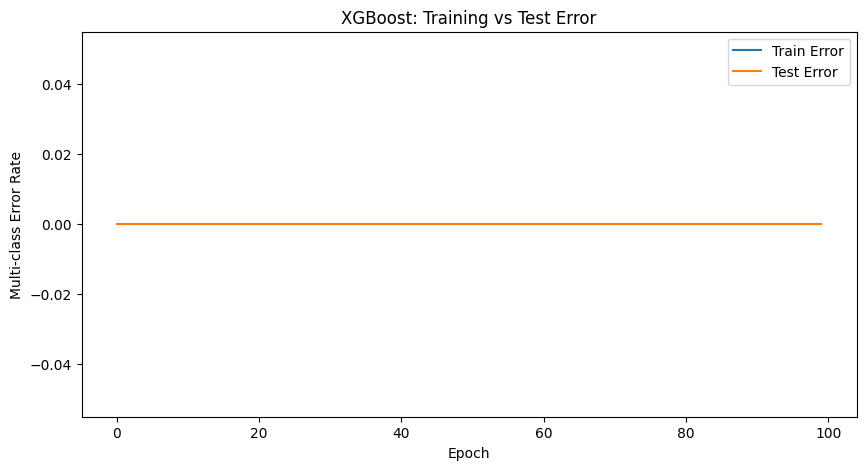

In [23]:
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml



# Define evaluation set
eval_set = [(X_train, y_train), (X_test, y_test)]

# Train the model
modelxgb = xgb.XGBClassifier(
    eval_metric=['merror', 'mlogloss'],
    use_label_encoder=False,
    objective='multi:softmax',
    num_class=10,
    tree_method='gpu_hist'  # Enable GPU acceleration
)

modelxgb.fit(
    X_train, 
    y_train,
    eval_set=eval_set,
    verbose=True
)

# Retrieve evaluation results
results = modelxgb.evals_result()
epochs = len(results['validation_0']['merror'])  # Changed 'error' to 'merror'
x_axis = range(epochs)

# Plot training and test error
plt.figure(figsize=(10, 5))
plt.plot(x_axis, results['validation_0']['merror'], label='Train Error')
plt.plot(x_axis, results['validation_1']['merror'], label='Test Error')
plt.xlabel('Epoch')
plt.ylabel('Multi-class Error Rate')
plt.title('XGBoost: Training vs Test Error')
plt.legend()
plt.show()

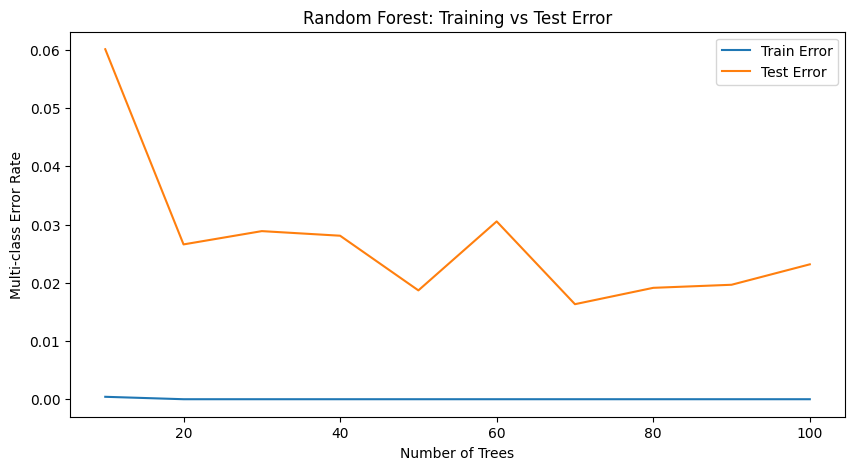

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss

# Train the model
model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=None,
    n_jobs=-1  # Use all CPU cores
)

model.fit(X_train, y_train)

# Since RandomForest doesn't have built-in evaluation tracking like XGBoost,
# we'll simulate it by tracking error across different forest sizes
train_errors = []
test_errors = []
logloss_train = []
logloss_test = []

# Evaluate incrementally (simulating epochs)
n_trees = range(10, 101, 10)  # 10, 20, ..., 100 trees
for n in n_trees:
    # Create a forest with n trees
    temp_model = RandomForestClassifier(n_estimators=n, n_jobs=-1)
    temp_model.fit(X_train, y_train)
    
    # Get predictions
    y_pred_train = temp_model.predict(X_train)
    y_pred_test = temp_model.predict(X_test)
    
    # Calculate error rates (1 - accuracy)
    train_error = 1 - accuracy_score(y_train, y_pred_train)
    test_error = 1 - accuracy_score(y_test, y_pred_test)
    
    # Get probabilities for log loss
    y_prob_train = temp_model.predict_proba(X_train)
    y_prob_test = temp_model.predict_proba(X_test)
    
    train_errors.append(train_error)
    test_errors.append(test_error)
    logloss_train.append(log_loss(y_train, y_prob_train))
    logloss_test.append(log_loss(y_test, y_prob_test))

# Plot training and test error
plt.figure(figsize=(10, 5))
plt.plot(n_trees, train_errors, label='Train Error')
plt.plot(n_trees, test_errors, label='Test Error')
plt.xlabel('Number of Trees')
plt.ylabel('Multi-class Error Rate')
plt.title('Random Forest: Training vs Test Error')
plt.legend()
plt.show()

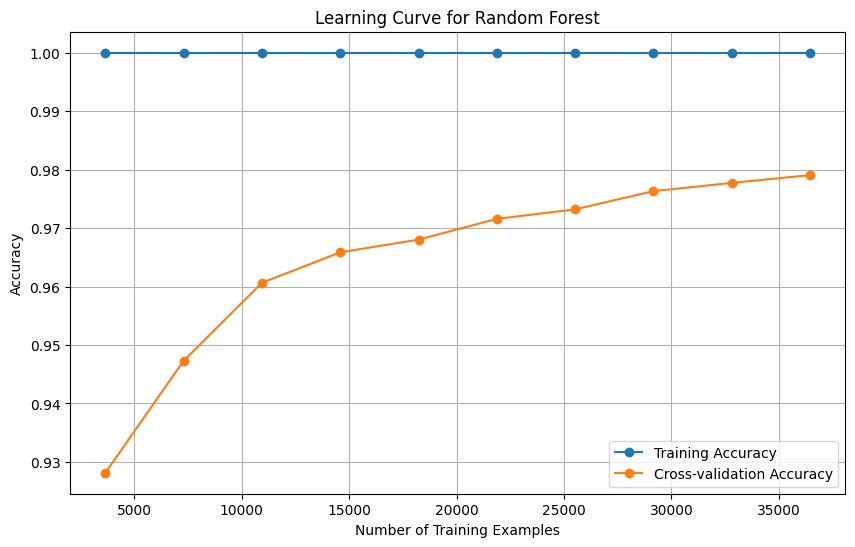

In [28]:
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Initialize the RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)

# Generate learning curve data (using 5-fold cross-validation)
train_sizes, train_scores, test_scores = learning_curve(
    estimator=model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Compute mean scores across folds
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Accuracy', marker='o')
plt.plot(train_sizes, test_scores_mean, label='Cross-validation Accuracy', marker='o')
plt.xlabel('Number of Training Examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve for Random Forest')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from bayes_opt import BayesianOptimization

def rf_csv(max_depth, n_estimators, min_samples_split, min_samples_leaf, max_features):
    params = {
        'max_depth': int(max_depth),
        'n_estimators': int(n_estimators),
        'min_samples_split': int(min_samples_split),
        'min_samples_leaf': int(min_samples_leaf),
        'max_features': max_features,
        'random_state': 42,
        'n_jobs': -1
    }
    
    cv_results = cross_val_score(
        RandomForestClassifier(**params),
        X_train, y_train,
        scoring='accuracy',
        cv=5
    )
    return cv_results.mean()





In [ ]:
pbounds = {
    'max_depth': (3, 12),
    'n_estimators': (100, 1000),
    'min_samples_split': (2, 10),
    'min_samples_leaf': (1, 5),
    'max_features': (0.1, 1.0)
}

optimizer = BayesianOptimization(
    f=rf_csv,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

In [ ]:

optimizer.maximize(
    init_points=10,
    n_iter=15
)

print(optimizer.max)

|   iter    |  target   | max_depth | max_fe... | min_sa... | min_sa... | n_esti... |
-------------------------------------------------------------------------------------
| 1         | 1.0       | 6.371     | 0.9556    | 3.928     | 6.789     | 240.4     |
| 2         | 0.7478    | 4.404     | 0.1523    | 4.465     | 6.809     | 737.3     |
| 3         | 0.9652    | 3.185     | 0.9729    | 4.33      | 3.699     | 263.6     |
| 4         | 0.881     | 4.651     | 0.3738    | 3.099     | 5.456     | 362.1     |
| 5         | 0.9439    | 8.507     | 0.2255    | 2.169     | 4.931     | 510.5     |
| 6         | 0.9861    | 10.07     | 0.2797    | 3.057     | 6.739     | 141.8     |
| 7         | 0.9567    | 8.468     | 0.2535    | 1.26      | 9.591     | 969.1     |
